# Spatial Transcriptomics — Microenvironment (Niche) Clustering Analysis Based on Neighborhood CellType Composition

This notebook implements a complete analytical workflow for spatial microenvironments:
1. **Spatial Neighborhood Search**: Search for neighboring cells around each cell using KNN radius search.
2. **Neighborhood Composition Statistics**: Calculate the proportion of each cell type within each cell's neighborhood.
3. **PCA + K-Means Clustering**: Perform dimensionality reduction and clustering on neighborhood compositions to identify spatial microenvironments (Niches).
4. **Spatial Visualization**: Map clustering results back to tissue spatial coordinates.
5. **Results Export**: Save the output to a CSV file for downstream analysis.

> **Prerequisites**: Pre-defined `df` (DataFrame containing `x`, `y`, `Cluster`, and `barcode` columns) are required.

## Import Dependencies

In [1]:
import pandas as pd
import numpy as np
import random
import time
import sys
from collections import Counter
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import seaborn as sns
# Set random seed for reproducibility
random.seed(123)
np.random.seed(123)
print("All dependency libraries imported successfully!")

All dependency libraries imported successfully!


## 1. Spatial Neighborhood Search

Perform radius neighborhood search using `sklearn.neighbors.NearestNeighbors`:
- Centered on the `(x, y)` coordinates of each cell.
- Search for all neighboring cells within the specified `radius`.
- Exclude self-loops (the cell itself).

In [3]:
# ========== Parameter Settings ==========
radius = 50  # Neighborhood search radius
output_path = "../Output/Breast_alpha_shape.csv"
df = pd.read_csv("../Data/Xenium_Breast_cancer.csv")
print(f"Total cells: {len(df)}")
print(f"Search radius: {radius}")
print(f"Cell types: {df['Cluster'].nunique()} types")

Total cells: 228796
Search radius: 50
Cell types: 15 types


In [4]:
# ========== Radius Neighborhood Search ==========
start_time = time.time()

# Build NearestNeighbors model 
fit = NearestNeighbors(radius=radius, algorithm='ball_tree').fit(df[["x", "y"]].values)

# radius_neighbors returns (distances, indices)
# distances: Array of distances from each cell to its neighbors
# indices: Array of neighbor indices for each cell
distances, indices = fit.radius_neighbors(df[["x", "y"]].values)

print(f"Neighborhood search completed in: {time.time() - start_time:.2f} seconds")
print(f"Range of neighbor count per cell: {min(len(i) for i in indices)} ~ {max(len(i) for i in indices)}")

Neighborhood search completed in: 0.92 seconds
Range of neighbor count per cell: 1 ~ 279


## 2. Construct Neighbor Index Matrix

Organize each cell's neighbor indices into a structured DataFrame while excluding the self-reference.

In [5]:
# ========== Extract Neighbor Indices, Excluding Self ==========
c_list = []  # Store row indices of neighbors for each cell 

for i in range(len(indices)):
    neighbor_indices = indices[i]
    if len(neighbor_indices) > 0:
        b = df.iloc[neighbor_indices, :].index
        b = b.drop(i)
        c_list.append(b)

print(f"Cells with neighbors: {len(c_list)}")
print(f"Average number of neighbors: {np.mean([len(n) for n in c_list]):.1f}")
print(f"Maximum number of neighbors: {max(len(n) for n in c_list)}")
print(f"Minimum number of neighbors: {min(len(n) for n in c_list)}")

Cells with neighbors: 228796
Average number of neighbors: 84.8
Maximum number of neighbors: 278
Minimum number of neighbors: 0


In [6]:
# ========== Construct Wide-Format Neighbor Index Matrix ==========
# Each row represents a cell, and each column represents its N-th neighbor
# Fill missing neighbor positions with NaN

max_neighbors = max(len(neighbors) for neighbors in c_list)
col_names = [f'Neighbor_{i}' for i in range(max_neighbors)]

neighbor_data = []
for neighbors in c_list:
    # Convert Index to list, padding missing positions with NaN
    row_data = neighbors.astype(int).tolist() + [np.nan] * (max_neighbors - len(neighbors))
    neighbor_data.append(row_data)

df_wide = pd.DataFrame(neighbor_data, columns=col_names)
print(f"Neighbor index matrix shape: {df_wide.shape}")


Neighbor index matrix shape: (228796, 278)


,Neighbor_0,Neighbor_1,Neighbor_2,Neighbor_3,Neighbor_4,Neighbor_5,Neighbor_6,Neighbor_7,Neighbor_8,Neighbor_9,...,Neighbor_268,Neighbor_269,Neighbor_270,Neighbor_271,Neighbor_272,Neighbor_273,Neighbor_274,Neighbor_275,Neighbor_276,Neighbor_277
0,3015.0,3024.0,3018.0,3017.0,3025.0,2.0,3036.0,3040.0,49.0,43.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3024.0,3018.0,3017.0,2828.0,2.0,47.0,4.0,3012.0,3026.0,3019.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3024.0,3018.0,3017.0,3040.0,49.0,46.0,3039.0,47.0,29.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,29.0,4.0,3012.0,3019.0,3013.0,28.0,3014.0,0.0,3020.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.0,45.0,49.0,43.0,46.0,47.0,29.0,3012.0,3019.0,48.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Calculate Neighborhood Cell-Type Proportions

Map neighbor indices to cell types (`Cluster`), then calculate the percentage of each cell type in every cell's neighborhood.


In [7]:
# ========== Map Neighbor Indices to Cell Types ==========
celltype_map = df["Cluster"].to_dict()
df_replaced = df_wide.apply(lambda col: col.map(lambda idx: celltype_map.get(idx, 'Unknown'))) # Use map to replace neighbor indices with corresponding cell types
 
print("Neighbor cell-type matrix:")
df_replaced.head()

Neighbor cell-type matrix:


,Neighbor_0,Neighbor_1,Neighbor_2,Neighbor_3,Neighbor_4,Neighbor_5,Neighbor_6,Neighbor_7,Neighbor_8,Neighbor_9,...,Neighbor_268,Neighbor_269,Neighbor_270,Neighbor_271,Neighbor_272,Neighbor_273,Neighbor_274,Neighbor_275,Neighbor_276,Neighbor_277
0,3,3,3,3,3,3,6,6,6,6,...,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
1,3,3,3,3,3,2,3,6,3,3,...,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
2,3,3,3,6,6,6,6,2,6,3,...,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
3,3,6,3,6,3,5,6,5,3,3,...,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
4,3,6,6,6,6,2,6,6,3,6,...,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown


In [8]:
# ========== Compute Percentage of Cell Types per Neighborhood (Row-wise) ==========
def calculate_percentage(row):
    """Calculate percentages of each cell type in a row."""
    neighbors = row.dropna().tolist()  # Remove NaNs (padding)
    neighbors = [n for n in neighbors if n != 'Unknown']  # Remove Unknowns
    total = len(neighbors)
    if total == 0:
        return {}
    counts = Counter(neighbors)
    return {k: (v / total) * 100 for k, v in counts.items()}

# Apply function to return a dict per row, then convert to DataFrame
df_percent = pd.DataFrame(
    df_replaced.apply(calculate_percentage, axis=1).tolist(),
    index=df_replaced.index
).fillna(0)  

print(f"Neighborhood feature matrix shape: {df_percent.shape}")
print(f"Cell type columns: {df_percent.columns.tolist()}")
df_percent.head()

Neighborhood feature matrix shape: (228796, 15)
Cell type columns: [3, 6, 2, 5, 4, 9, 7, 0, 10, 12, 1, 11, 8, 13, 14]


,3,6,2,5,4,9,7,0,10,12,1,11,8,13,14
0,64.583333,29.166667,2.083333,4.166667,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,85.106383,8.510638,2.127660,4.255319,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,72.000000,22.000000,2.000000,4.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,76.666667,13.333333,1.666667,6.666667,1.666667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,47.058824,39.705882,2.941176,5.882353,4.411765,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


/tmp/ipykernel_2575978/1894925757.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_percent.index, y=mean_percent.values, palette="Set2")


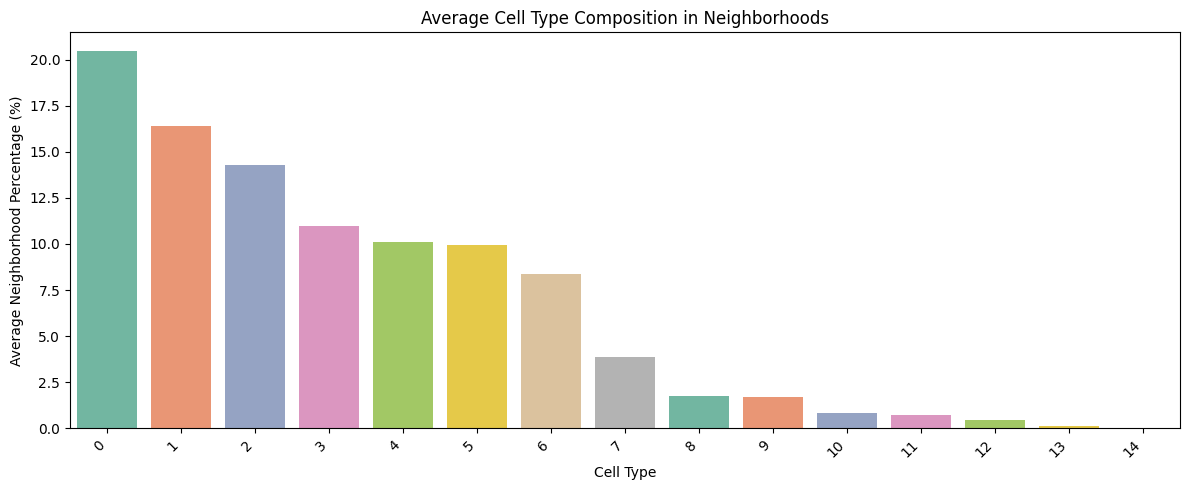

In [9]:
# ========== Visualization: Mean Neighborhood Percentage per Cell Type ==========

mean_percent = df_percent.mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=mean_percent.index, y=mean_percent.values, palette="Set2")
plt.xlabel("Cell Type")
plt.ylabel("Average Neighborhood Percentage (%)")
plt.title("Average Cell Type Composition in Neighborhoods")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. PCA Dimensionality Reduction + K-Means Clustering (Microenvironment Identification)

Process the neighborhood composition matrix:
1. **Standardization** (`StandardScaler`): Eliminate scale differences.
2. **PCA Dimensionality Reduction**: Retain 95% variance to reduce noise and redundancy.
3. **MiniBatchKMeans Clustering**: Suitable for large datasets and memory-friendly.
4. **Silhouette Score**: Evaluate clustering quality to select the optimal K value.

In [10]:
# ========== Data Standardization + PCA ==========
# Z-score standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_percent)
# PCA: Retain 95% variance
pca = PCA(n_components=0.95, random_state=123)
X_pca = pca.fit_transform(X_scaled)
print(f"Feature dimensions after standardization: {X_scaled.shape[1]}")
print(f"Feature dimensions after PCA: {X_pca.shape[1]}")
print(f"Explained variance ratio per principal component: {pca.explained_variance_ratio_}")
print(f"Cumulative explained variance: {sum(pca.explained_variance_ratio_):.4f}")

Feature dimensions after standardization: 15
Feature dimensions after PCA: 13
Explained variance ratio per principal component: [0.17452505 0.13631422 0.09250518 0.07902211 0.07151106 0.06777516
 0.06099838 0.05909046 0.05578206 0.05024212 0.0430521  0.04140544
 0.04036446]
Cumulative explained variance: 0.9726


## 5. Select Optimal K Value (Silhouette Score Method)
Iterate through K=2~10 and calculate the Silhouette Score for each K value.
- **Silhouette Score Range**: [-1, 1]; higher values indicate better clustering performance.
- Plot the trend line to assist judgment.

In [ ]:
# ========== Iterate K values to compute Silhouette Scores ==========

k_range = range(2, 10)
silhouette_scores = []

for k in k_range:
    km = MiniBatchKMeans(
        n_clusters=k,
        batch_size=256,
        random_state=123,
        n_init=3,       # Multiple initializations to find optimal
        max_iter=100
    )
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

# Optimal K value 
optimal_k = np.argmax(silhouette_scores) + 2  # +2 because range starts at 2
print(f"\n>>> Recommended Optimal K by Silhouette Score = {optimal_k} (score={max(silhouette_scores):.4f})")

K=2, Silhouette Score=0.2004
K=3, Silhouette Score=0.1689


In [ ]:
# ========== Visualization: Silhouette Score vs K Value ==========

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o', linewidth=2, markersize=8, color='steelblue')

# Highlight optimal point
plt.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.7, label=f'Optimal K={optimal_k}')
plt.scatter(optimal_k, max(silhouette_scores), color='red', s=100, zorder=5)

plt.xlabel('K (Number of Clusters)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs K for Niche Clustering', fontsize=14)
plt.xticks(k_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Final Clustering & Spatial Visualization

Perform final clustering based on the selected K value, then map cluster labels back to spatial coordinates for visualization.

> **Note**: The K value can be selected comprehensively based on recommended Silhouette Scores and biological context.

In [ ]:
# ========== Final K-Means Clustering ==========
# Select K value (refer to Silhouette Score recommendation or specify manually)
k = optimal_k  # Use recommended K
print(f"Performing final clustering with K = {k}...")
km_final = MiniBatchKMeans(
    n_clusters=k,
    batch_size=256,
    random_state=123,
    n_init=5,
    max_iter=200
)
labels = km_final.fit_predict(X_pca)
df["niche_cluster"] = labels
cluster_counts = df["niche_cluster"].value_counts().sort_index()
print(f"\nCell count per microenvironment cluster:")
for cluster_id, count in cluster_counts.items():
    print(f"  Niche {cluster_id}: {count} cells ({count/len(df)*100:.1f}%)")

In [ ]:
# ========== Spatial Visualization: Clustering Results ==========
plt.figure(figsize=(20, 8))
sns.scatterplot(
    data=df,x="x",y="y",hue="niche_cluster",palette="tab20",s=15,  alpha=0.7,         
    edgecolor=None,   
    legend="full"
)
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(400)) 
ax.yaxis.set_major_locator(MultipleLocator(400))  
ax.xaxis.set_minor_locator(AutoMinorLocator(n=5))  
ax.yaxis.set_minor_locator(AutoMinorLocator(n=5))  
ax.grid(which="minor", linestyle=":", linewidth=0.5, color="lightgray", alpha=0.5)
ax.grid(which="major", linestyle="-", linewidth=0.8, color="gray", alpha=0.3)
plt.title(f'Spatial Niche Clustering (K={k})', fontsize=16, fontweight='bold')
plt.xlabel('X coordinate', fontsize=12)
plt.ylabel('Y coordinate', fontsize=12)
plt.tight_layout()
plt.savefig("spatial_niche_clustering.png", dpi=150, bbox_inches='tight')
plt.show()
print("Image saved as spatial_niche_clustering.png")

In [ ]:
# ========== Supplementary Visualization: Stacked Bar Plot of Cell-Type Composition per Niche ==========

# Add cluster labels to df_percent
df_percent_labeled = df_percent.copy()
df_percent_labeled['niche_cluster'] = labels

# Calculate mean proportion of each cell type per Niche
niche_composition = df_percent_labeled.groupby('niche_cluster').mean()

# Stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))
niche_composition.plot(kind='bar', stacked=True, ax=ax, colormap='Set3')

plt.xlabel('Niche Cluster', fontsize=12)
plt.ylabel('Average Cell Type Proportion (%)', fontsize=12)
plt.title('Cell Type Composition per Spatial Niche', fontsize=14)
plt.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("niche_composition.png", dpi=150, bbox_inches='tight')
plt.show()

print("Image saved as niche_composition.png")

## 7. Export Results

In [ ]:
# ========== Export Results to CSV ==========
df = df.set_index('barcode')
df.to_csv(output_path)
print(f"Results saved to: {output_path}")
print(f"Output DataFrame shape: {df.shape}")
print(f"Output columns: {df.columns.tolist()}")
df.head()